# S04.00 — Introducción y EDA del Dataset Sintético v2
## Módulo 3, Tema 1: Introducción a Machine Learning — Subtema 4

**Objetivo del módulo:**
Familiarizarse con el dataset sintético v2 de seguros de autos, sus 21 columnas,
distribuciones y relaciones entre features y targets. Establecer el flujo de
preparación que se reutilizará en los notebooks S04.01–S04.11.

**Al terminar este notebook podrás:**
1. Describir el schema del dataset v2 (roles, tipos, rangos).
2. Distinguir `FEATURE_COLUMNS`, `TARGET_COLUMNS` y `CLUSTERING_FEATURES`.
3. Identificar relaciones descriptivas entre features y targets sin entrenar modelos.
4. Aplicar la regla de leakage a los 5 targets del Subtema 4.
5. Reproducir el template de carga que cada notebook S04.01–S04.11 utiliza.

---

## 1. Contexto actuarial

Las aseguradoras de autos recopilan información sobre el asegurado, el vehículo
y el producto al emitir cada póliza. Con esa información, el área actuarial debe
responder tres tipos de preguntas:

| Pregunta | Tipo de tarea de ML | Variable respuesta |
|----------|--------------------|--------------------|
| ¿Cuánto cobrar de prima? | Regresión | `prima_neta` (MXN) |
| ¿Ocurrirá un siniestro? | Clasificación binaria | `siniestro_alto` (0/1) |
| ¿Qué perfil tiene el asegurado? | Clustering (no supervisado) | Sin variable respuesta |

El **dataset sintético v2** tiene 30,000 pólizas con 21 columnas. Las relaciones
causales están explícitamente diseñadas, lo que permite verificar la intuición
contra el código del generador. No contiene PII.

> *Fuente actuarial:* Wüthrich & Buser, *Data Analytics for Non-Life Insurance Pricing*, Cap. 1.

## 2. Carga del dataset

In [17]:
import simulate_portfolio_v2

print(simulate_portfolio_v2.__file__)

/Users/valeria/Desktop/System Volume Information/Tareas ric/Diplomado/diplomado-ml-ricardo-benitez/Material_Mod3/simulate_portfolio_v2.py


In [19]:
import sys
from pathlib import Path

# Localizar src/ sin importar desde qué directorio se lance el kernel.
# Candidatos en orden: raíz del proyecto, un nivel arriba, dos niveles arriba.
_candidates = [
    Path.cwd() / "",
    Path.cwd().parent / "",
    Path.cwd().parent.parent / "",
]
_src_path = next(
    (p for p in _candidates if (p / "simulate_portfolio_v2.py").exists()),
    None,
)
if _src_path is None:
    raise FileNotFoundError(
        "No se encontró simulate_portfolio_v2.py en ningún candidato: "
        + str([str(p) for p in _candidates])
        + " — ejecutar el notebook desde la raíz del proyecto "
          "o desde content/notebooks/."
    )
sys.path.insert(0, str(_src_path))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import simulate_portfolio_v2

importlib.reload(simulate_portfolio_v2)

from simulate_portfolio_v2 import (
    simulate_auto_insurance_portfolio_v2,
    ALL_COLUMNS,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
    CLUSTERING_FEATURES,
    PII_COLUMNS_FORBIDDEN,
)

# Constantes del proyecto
SEED = 20260618
N_POLICIES = 30_000
NAVY = "#003B5C"
GOLD = "#C8A33A"
RED  = "#C0392B"

plt.rcParams.update({"figure.dpi": 100, "font.size": 11})
sns.set_theme(style="whitegrid")

# Generar dataset con la semilla base del proyecto
df = simulate_auto_insurance_portfolio_v2(n_policies=N_POLICIES, seed=SEED)
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")


Dataset cargado: 30,000 filas × 24 columnas


## 3. Revisión de columnas y tipos

In [22]:
# Schema de las 21 columnas con rol y dtype pandas
_roles = (
    ["Índice"]
    + ["Feature"] * 18
    + ["Target regresión", "Target conteo", "Target reg. condicional",
       "Target binario", "Target multinomial"]
)
schema_df = pd.DataFrame({
    "Col #": range(1, 25),
    "Columna": ALL_COLUMNS,
    "Rol": _roles,
    "dtype": [str(df[c].dtype) for c in ALL_COLUMNS],
})
print(schema_df.to_string(index=False))

 Col #               Columna                     Rol    dtype
     1         id_poliza_sin                  Índice   object
     2           anio_poliza                 Feature    int64
     3           mes_emision                 Feature    int64
     4                  edad                 Feature    int64
     5                  sexo                 Feature category
     6          estado_civil                 Feature category
     7      num_renovaciones                 Feature    int64
     8                region                 Feature category
     9                  plan                 Feature category
    10         tipo_vehiculo                 Feature category
    11   antiguedad_vehiculo                 Feature    int64
    12        suma_asegurada                 Feature  float64
    13         deducible_pct                 Feature  float64
    14            forma_pago                 Feature category
    15           canal_venta                 Feature category
    16  

In [23]:
# Resumen de conteos por tipo
print("Columnas categóricas (dtype=category):")
print([c for c in df.columns if df[c].dtype.name == "category"])
print()
print("Columnas enteras:")
print([c for c in df.columns if pd.api.types.is_integer_dtype(df[c])])
print()
print("Primeras 2 filas de muestra:")
df.head(2)

Columnas categóricas (dtype=category):
['sexo', 'estado_civil', 'region', 'plan', 'tipo_vehiculo', 'forma_pago', 'canal_venta', 'nivel_riesgo_asignado', 'status_poliza', 'uso_vehiculo', 'tipo_garage']

Columnas enteras:
['anio_poliza', 'mes_emision', 'edad', 'num_renovaciones', 'antiguedad_vehiculo', 'n_siniestros', 'siniestro_alto', 'kilometraje']

Primeras 2 filas de muestra:


,id_poliza_sin,anio_poliza,mes_emision,edad,sexo,estado_civil,num_renovaciones,region,plan,tipo_vehiculo,...,canal_venta,nivel_riesgo_asignado,prima_neta,n_siniestros,monto_siniestro,siniestro_alto,status_poliza,kilometraje,uso_vehiculo,tipo_garage
0,SIN-000001,2025,8,55,M,viudo,0,Centro,Basico,Compacto,...,Directo,Medio,6270.52,0,0.0,0,Vigente,14213,Particular,Propio
1,SIN-000002,2021,12,33,F,casado,0,Occidente,Basico,Sedan,...,Directo,Bajo,10655.20,0,0.0,0,Vigente,18249,Particular,Propio


## 4. Separación de features, targets y clustering features

Cada notebook del Subtema 4 importa estas tres listas directamente desde
`simulate_portfolio_v2`. Son la interfaz estándar del dataset.

In [24]:
print(f"FEATURE_COLUMNS  ({len(FEATURE_COLUMNS)}):")
print(" ", FEATURE_COLUMNS)
print()
print(f"TARGET_COLUMNS   ({len(TARGET_COLUMNS)}):")
print(" ", TARGET_COLUMNS)
print()
print(f"CLUSTERING_FEATURES ({len(CLUSTERING_FEATURES)}):")
print(" ", CLUSTERING_FEATURES)

# Verificar separación §2.2: targets nunca en clustering features
# cuidar el leakage
assert set(CLUSTERING_FEATURES).isdisjoint(set(TARGET_COLUMNS)), (
    "CLUSTERING_FEATURES contiene targets — violación §2.2"
)
assert set(PII_COLUMNS_FORBIDDEN).isdisjoint(set(ALL_COLUMNS)), (
    "Columnas PII encontradas en ALL_COLUMNS"
)
print()
print("✓ CLUSTERING_FEATURES ∩ TARGET_COLUMNS = ∅  (sin leakage de targets en clustering)")
print("✓ Ninguna columna PII aparece en ALL_COLUMNS")

FEATURE_COLUMNS  (18):
  ['anio_poliza', 'mes_emision', 'edad', 'sexo', 'estado_civil', 'num_renovaciones', 'region', 'plan', 'tipo_vehiculo', 'antiguedad_vehiculo', 'suma_asegurada', 'deducible_pct', 'forma_pago', 'canal_venta', 'kilometraje', 'uso_vehiculo', 'tipo_garage', 'nivel_riesgo_asignado']

TARGET_COLUMNS   (5):
  ['prima_neta', 'n_siniestros', 'monto_siniestro', 'siniestro_alto', 'status_poliza']

CLUSTERING_FEATURES (5):
  ['edad', 'suma_asegurada', 'num_renovaciones', 'antiguedad_vehiculo', 'kilometraje']

✓ CLUSTERING_FEATURES ∩ TARGET_COLUMNS = ∅  (sin leakage de targets en clustering)
✓ Ninguna columna PII aparece en ALL_COLUMNS


### Diagrama: features → targets

```
FEATURE_COLUMNS (15)                     TARGET_COLUMNS (5)
──────────────────────────────           ──────────────────────────────────────
anio_poliza       forma_pago             prima_neta      → regresión  (S04.01–S04.06, S04.08)
mes_emision       canal_venta            n_siniestros    → conteo Poisson
edad              nivel_riesgo_asignado  monto_siniestro → regresión condicional
sexo                                     siniestro_alto  → clasificación binaria (S04.03, S04.07)
estado_civil                             status_poliza   → clasificación multinomial
num_renovaciones  ────────────────────
region            CLUSTERING_FEATURES (subconjunto de FEATURE_COLUMNS):
plan              edad, suma_asegurada, num_renovaciones, antiguedad_vehiculo
tipo_vehiculo
antiguedad_vehiculo   Regla §2.2: TARGET_COLUMNS nunca entra como
suma_asegurada        variable de clustering. Se compara contra
deducible_pct         clusters como ejercicio posterior (S04.09–S04.11).
```


## 5. Validaciones rápidas §6.4

Las 7 validaciones del diseño técnico garantizan la integridad del dataset.
Este bloque las verifica en el notebook antes de cualquier análisis.

In [25]:
# validaciones: verifica que todo se cumpla
assert df.shape == (30_000, 24), f"Shape: {df.shape}"
print("✓ V1: shape == (30_000, 24)")

nulos = df.isnull().sum().sum()
assert nulos == 0, f"Nulos: {nulos}"
print("✓ V2: cero nulos en todas las columnas")

assert (df["siniestro_alto"] == (df["n_siniestros"] > 0).astype(int)).all()
print("✓ V3: siniestro_alto == int(n_siniestros > 0) en todas las filas")

assert (df.loc[df["n_siniestros"] == 0, "monto_siniestro"] == 0.0).all()
print("✓ V4: monto_siniestro == 0.0 cuando n_siniestros == 0")

assert df["prima_neta"].min() > 0
print(f"✓ V5: prima_neta.min() = {df['prima_neta'].min():,.2f} MXN (> 0)")

df_check = simulate_auto_insurance_portfolio_v2(n_policies=N_POLICIES, seed=SEED)
assert df.equals(df_check)
del df_check
print("✓ V6: reproducibilidad con seed=20260618 confirmada")

assert df["n_siniestros"].max() <= 5
print(f"✓ V7: n_siniestros.max() = {df['n_siniestros'].max()} (≤ 5)")
print()
print("✓ Las 7 validaciones §6.4 pasan")

✓ V1: shape == (30_000, 24)
✓ V2: cero nulos en todas las columnas
✓ V3: siniestro_alto == int(n_siniestros > 0) en todas las filas
✓ V4: monto_siniestro == 0.0 cuando n_siniestros == 0
✓ V5: prima_neta.min() = 1,261.20 MXN (> 0)
✓ V6: reproducibilidad con seed=20260618 confirmada
✓ V7: n_siniestros.max() = 5 (≤ 5)

✓ Las 7 validaciones §6.4 pasan


## 6. Análisis univariado de features clave

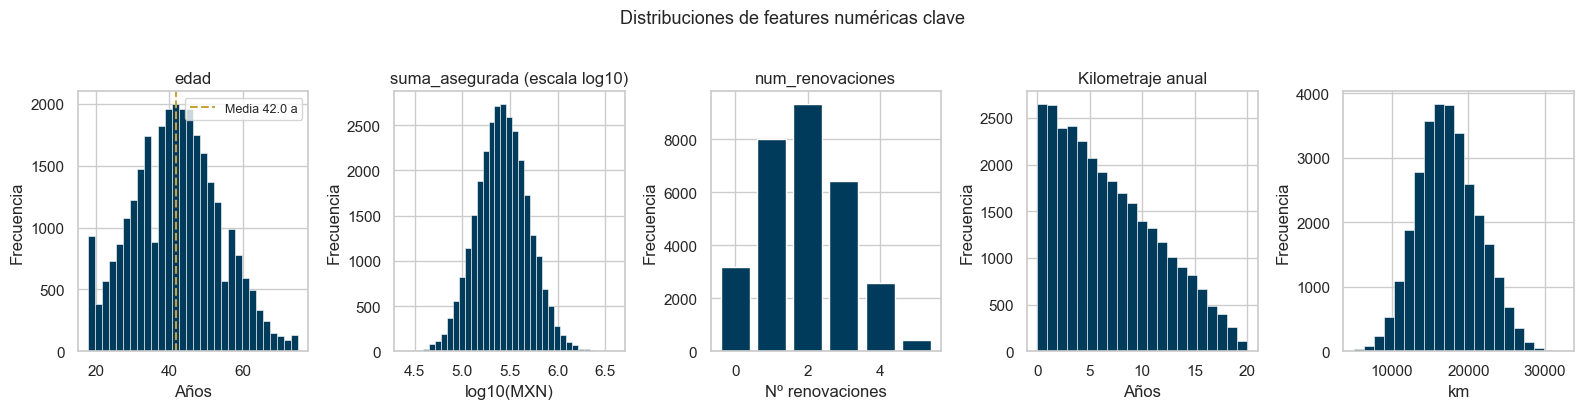

In [26]:
# Features numéricas: edad, suma_asegurada (log), num_renovaciones, antiguedad_vehiculo
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

axes[0].hist(df["edad"], bins=30, color=NAVY, edgecolor="white", linewidth=0.4)
axes[0].axvline(df["edad"].mean(), color=GOLD, linestyle="--", linewidth=1.5,
                label=f"Media {df['edad'].mean():.1f} a")
axes[0].set_xlabel("Años"); axes[0].set_title("edad"); axes[0].legend(fontsize=9)

axes[1].hist(np.log10(df["suma_asegurada"]), bins=35, color=NAVY, edgecolor="white", linewidth=0.4)
axes[1].set_xlabel("log10(MXN)"); axes[1].set_title("suma_asegurada (escala log10)")

reno = df["num_renovaciones"].value_counts().sort_index()
axes[2].bar(reno.index, reno.values, color=NAVY, edgecolor="white")
axes[2].set_xlabel("Nº renovaciones"); axes[2].set_title("num_renovaciones")

axes[3].hist(df["antiguedad_vehiculo"], bins=21, color=NAVY, edgecolor="white", linewidth=0.4)
axes[3].set_xlabel("Años"); axes[3].set_title("antiguedad_vehiculo")

axes[4].hist(df["kilometraje"], bins=21, color=NAVY, edgecolor="white", linewidth=0.4)
axes[4].set_xlabel("km"); axes[3].set_title("Kilometraje anual")

for ax in axes:
    ax.set_ylabel("Frecuencia")
fig.suptitle("Distribuciones de features numéricas clave", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

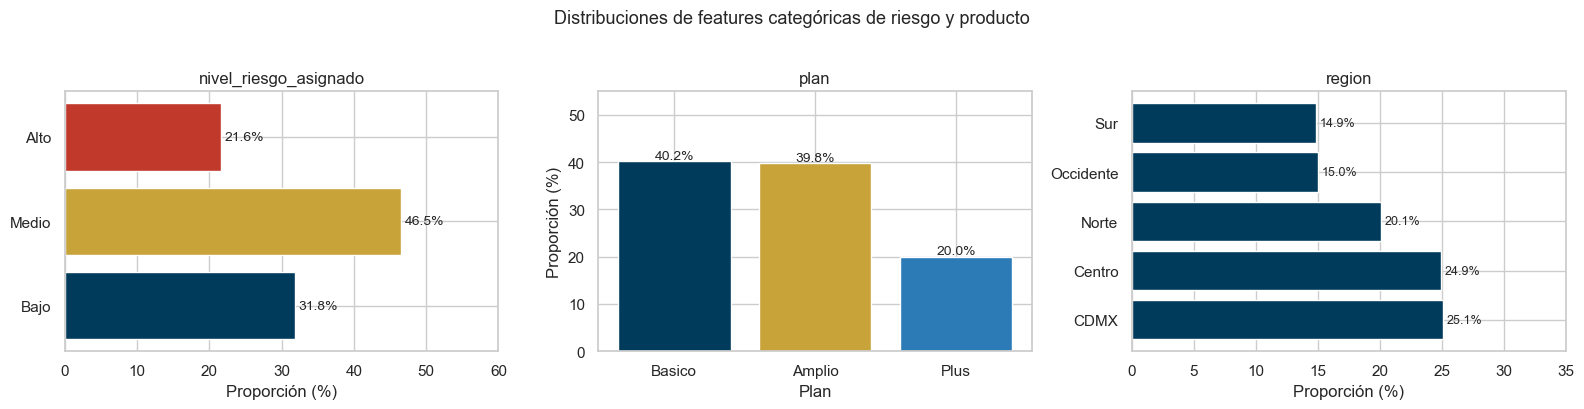

In [10]:
# Features categóricas de riesgo y producto
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# nivel_riesgo_asignado con proporciones etiquetadas
riesgo_pct = df["nivel_riesgo_asignado"].value_counts(normalize=True).mul(100).reindex(["Bajo","Medio","Alto"])
colors_r = [NAVY, GOLD, RED]
bars = axes[0].barh(riesgo_pct.index, riesgo_pct.values, color=colors_r)
axes[0].set_xlabel("Proporción (%)"); axes[0].set_title("nivel_riesgo_asignado"); axes[0].set_xlim(0, 60)
for bar, val in zip(bars, riesgo_pct.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=10)

# plan
plan_pct = df["plan"].value_counts(normalize=True).mul(100).reindex(["Basico","Amplio","Plus"])
bars2 = axes[1].bar(plan_pct.index, plan_pct.values, color=[NAVY, GOLD, "#2C7BB6"])
axes[1].set_xlabel("Plan"); axes[1].set_ylabel("Proporción (%)"); axes[1].set_title("plan"); axes[1].set_ylim(0, 55)
for bar, val in zip(bars2, plan_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5, f"{val:.1f}%", ha="center", fontsize=10)

# region
region_pct = df["region"].value_counts(normalize=True).mul(100)
bars3 = axes[2].barh(region_pct.index, region_pct.values, color=NAVY)
axes[2].set_xlabel("Proporción (%)"); axes[2].set_title("region"); axes[2].set_xlim(0, 35)
for bar, val in zip(bars3, region_pct.values):
    axes[2].text(val + 0.3, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)

fig.suptitle("Distribuciones de features categóricas de riesgo y producto", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 7. Análisis de los 5 targets

/var/folders/k1/_jflqvn90v31fwxjw3lf6y680000gn/T/ipykernel_22220/319977693.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.show()


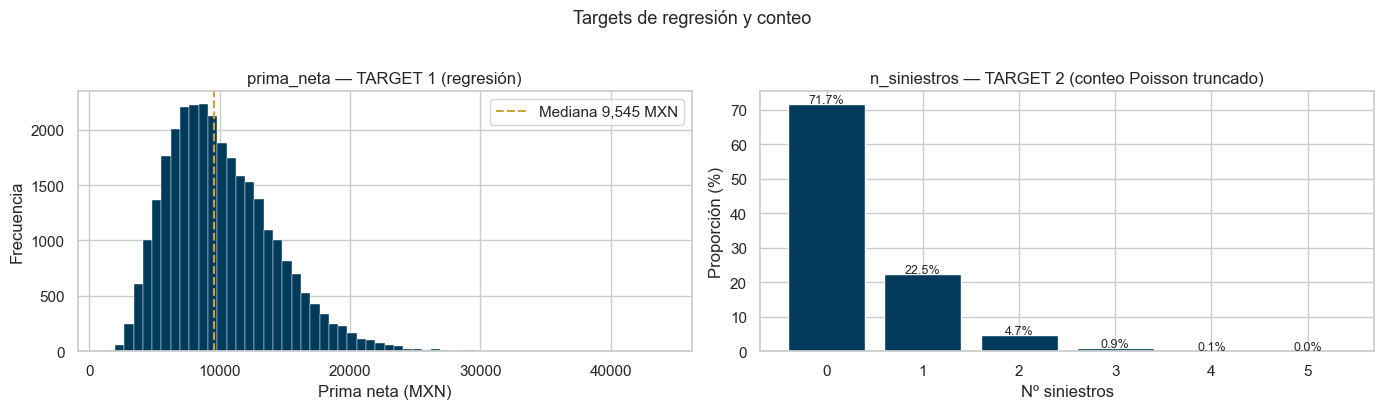

prima_neta — min: 1,261 | mediana: 9,545 | max: 44,073 MXN
n_siniestros==0: 71.7% de las pólizas (siniestralidad: 28.3%)


In [11]:
# Target 1: prima_neta | Target 2: n_siniestros
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["prima_neta"], bins=60, color=NAVY, edgecolor="white", linewidth=0.3)
axes[0].axvline(df["prima_neta"].median(), color=GOLD, linestyle="--", linewidth=1.5,
                label=f"Mediana {df['prima_neta'].median():,.0f} MXN")
axes[0].set_xlabel("Prima neta (MXN)"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("prima_neta — TARGET 1 (regresión)"); axes[0].legend()

nsins = df["n_siniestros"].value_counts(normalize=True).sort_index().mul(100)
axes[1].bar(nsins.index, nsins.values, color=NAVY, edgecolor="white")
axes[1].set_xlabel("Nº siniestros"); axes[1].set_ylabel("Proporción (%)")
axes[1].set_title("n_siniestros — TARGET 2 (conteo Poisson truncado)")
for k, v in nsins.items():
    axes[1].text(k, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)

fig.suptitle("Targets de regresión y conteo", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()
pct_sin = df["siniestro_alto"].mean() * 100
print(f"prima_neta — min: {df['prima_neta'].min():,.0f} | mediana: {df['prima_neta'].median():,.0f} | max: {df['prima_neta'].max():,.0f} MXN")
print(f"n_siniestros==0: {100 - pct_sin:.1f}% de las pólizas (siniestralidad: {pct_sin:.1f}%)")

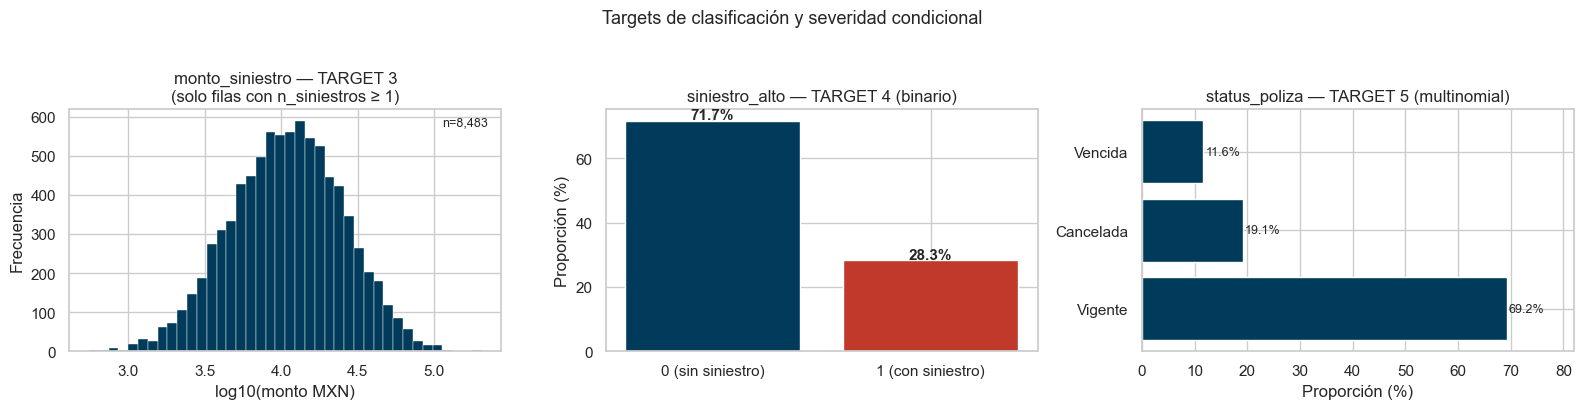

In [12]:
# Target 3: monto_siniestro (condicional) | Target 4: siniestro_alto | Target 5: status_poliza
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# monto_siniestro solo donde n_siniestros > 0
monto_pos = df.loc[df["n_siniestros"] > 0, "monto_siniestro"]
axes[0].hist(np.log10(monto_pos), bins=40, color=NAVY, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("log10(monto MXN)"); axes[0].set_ylabel("Frecuencia")
axes[0].set_title("monto_siniestro — TARGET 3\n(solo filas con n_siniestros ≥ 1)")
axes[0].text(0.97, 0.97, f"n={len(monto_pos):,}", transform=axes[0].transAxes,
             ha="right", va="top", fontsize=9)

# siniestro_alto
sa_pct = df["siniestro_alto"].value_counts(normalize=True).sort_index().mul(100)
bars_sa = axes[1].bar(["0 (sin siniestro)", "1 (con siniestro)"], sa_pct.values, color=[NAVY, RED])
axes[1].set_ylabel("Proporción (%)"); axes[1].set_title("siniestro_alto — TARGET 4 (binario)")
for bar, val in zip(bars_sa, sa_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

# status_poliza
status_pct = df["status_poliza"].value_counts(normalize=True).mul(100)
bars_st = axes[2].barh(status_pct.index, status_pct.values, color=NAVY)
axes[2].set_xlabel("Proporción (%)"); axes[2].set_title("status_poliza — TARGET 5 (multinomial)"); axes[2].set_xlim(0, 82)
for bar, val in zip(bars_st, status_pct.values):
    axes[2].text(val + 0.4, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=9)

fig.suptitle("Targets de clasificación y severidad condicional", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 8. Relaciones descriptivas features → targets

Las siguientes gráficas verifican las relaciones causales diseñadas en el generador.
**No se entrena ningún modelo en esta sección.**

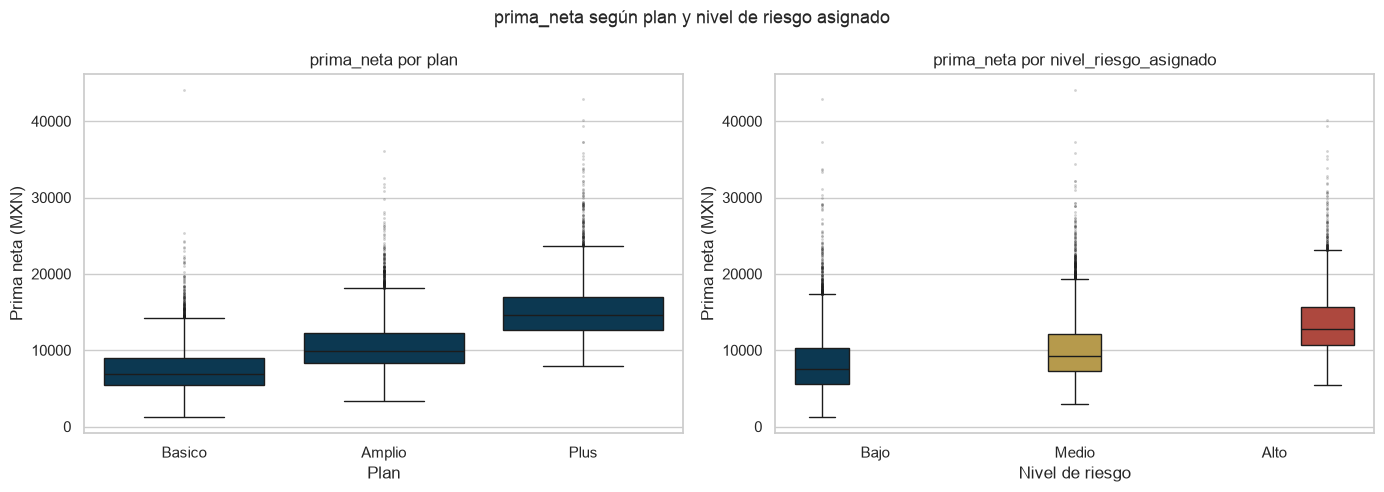

Mediana prima_neta por plan (MXN):
plan
Basico     6929.175
Amplio     9925.850
Plus      14576.180

Mediana prima_neta por nivel_riesgo_asignado (MXN):
nivel_riesgo_asignado
Bajo      7484.530
Medio     9299.025
Alto     12770.490


In [10]:
# Boxplot prima_neta × plan | prima_neta × nivel_riesgo_asignado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="plan", y="prima_neta", order=["Basico","Amplio","Plus"],
            color=NAVY, flierprops=dict(marker=".", alpha=0.2, markersize=2), ax=axes[0])
axes[0].set_title("prima_neta por plan"); axes[0].set_xlabel("Plan"); axes[0].set_ylabel("Prima neta (MXN)")

sns.boxplot(data=df, x="nivel_riesgo_asignado", y="prima_neta",
            order=["Bajo","Medio","Alto"],
            hue="nivel_riesgo_asignado",
            palette={"Bajo": NAVY, "Medio": GOLD, "Alto": RED},
            flierprops=dict(marker=".", alpha=0.2, markersize=2),
            ax=axes[1], legend=False)
axes[1].set_title("prima_neta por nivel_riesgo_asignado")
axes[1].set_xlabel("Nivel de riesgo"); axes[1].set_ylabel("Prima neta (MXN)")

fig.suptitle("prima_neta según plan y nivel de riesgo asignado", fontsize=13)
plt.tight_layout(); plt.show()

print("Mediana prima_neta por plan (MXN):")
print(df.groupby("plan", observed=True)["prima_neta"].median().to_string())
print("\nMediana prima_neta por nivel_riesgo_asignado (MXN):")
print(df.groupby("nivel_riesgo_asignado", observed=True)["prima_neta"].median().reindex(["Bajo","Medio","Alto"]).to_string())

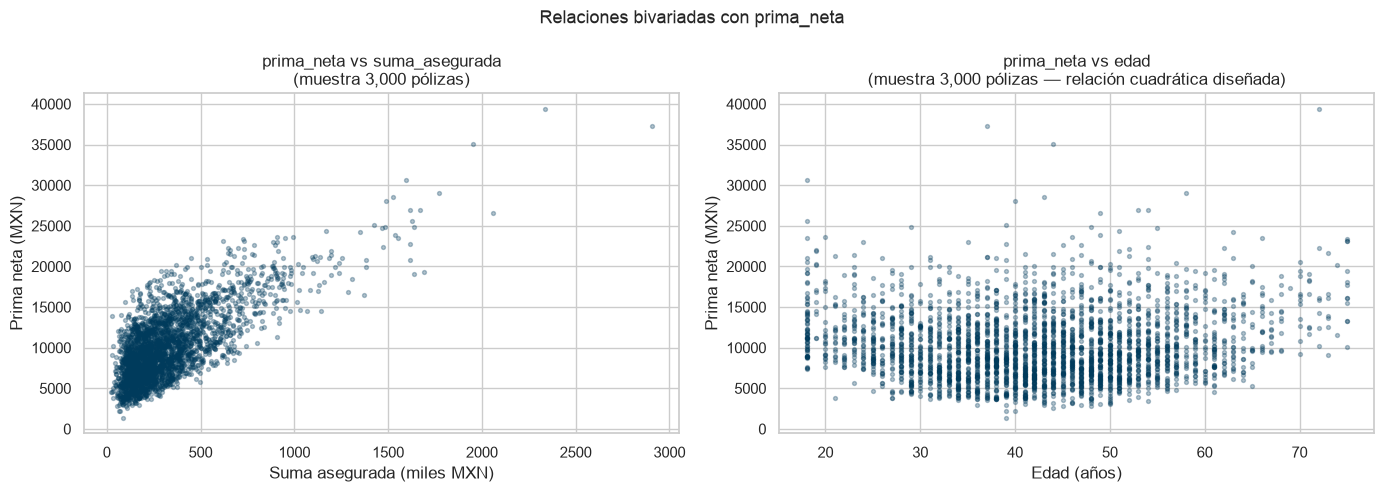

Correlación Pearson prima_neta vs suma_asegurada: 0.699
Correlación Pearson prima_neta vs edad:           0.044
  Nota: la relación con edad es cuadrática (β₂·edad_c + β₃·edad_c²).
  S04.02 (regresión polinómica) la capturará mejor que S04.01.


In [11]:
# Scatter prima_neta vs suma_asegurada | prima_neta vs edad (muestra de 3,000)
df_sample = df.sample(3_000, random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_sample["suma_asegurada"] / 1_000, df_sample["prima_neta"],
                alpha=0.3, s=8, color=NAVY)
axes[0].set_xlabel("Suma asegurada (miles MXN)"); axes[0].set_ylabel("Prima neta (MXN)")
axes[0].set_title("prima_neta vs suma_asegurada\n(muestra 3,000 pólizas)")

axes[1].scatter(df_sample["edad"], df_sample["prima_neta"],
                alpha=0.3, s=8, color=NAVY)
axes[1].set_xlabel("Edad (años)"); axes[1].set_ylabel("Prima neta (MXN)")
axes[1].set_title("prima_neta vs edad\n(muestra 3,000 pólizas — relación cuadrática diseñada)")

fig.suptitle("Relaciones bivariadas con prima_neta", fontsize=13)
plt.tight_layout(); plt.show()

print(f"Correlación Pearson prima_neta vs suma_asegurada: {df['prima_neta'].corr(df['suma_asegurada']):.3f}")
print(f"Correlación Pearson prima_neta vs edad:           {df['prima_neta'].corr(df['edad']):.3f}")
print("  Nota: la relación con edad es cuadrática (β₂·edad_c + β₃·edad_c²).")
print("  S04.02 (regresión polinómica) la capturará mejor que S04.01.")

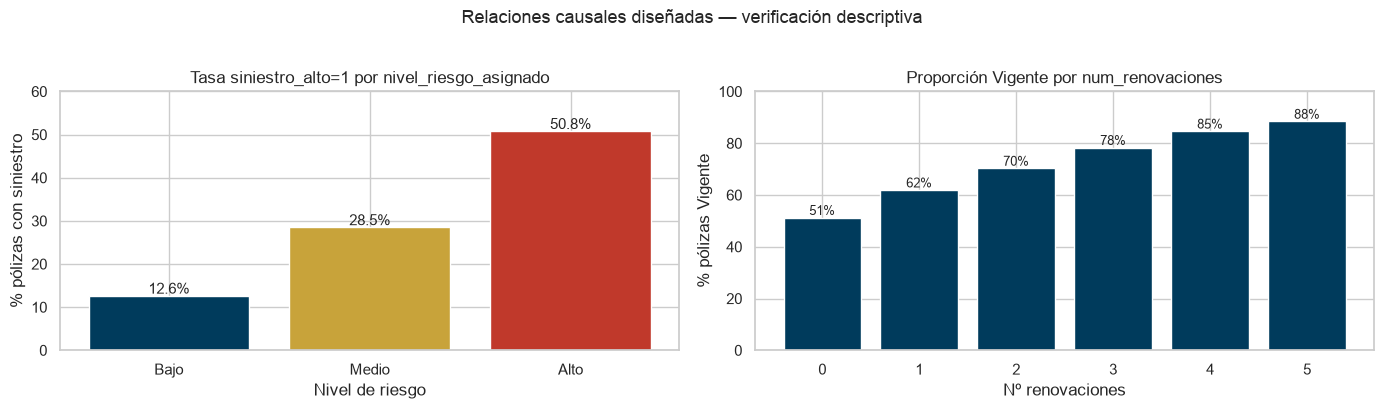

Tasa siniestro_alto=1 por nivel de riesgo (diseñado: Bajo λ≈0.12, Medio λ≈0.28, Alto λ≈0.55):
nivel_riesgo_asignado
Bajo     12.627056
Medio    28.498782
Alto     50.792918


In [12]:
# Tasa siniestro_alto=1 por nivel_riesgo | Proporción Vigente por num_renovaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

tasa_sin = (df.groupby("nivel_riesgo_asignado", observed=True)["siniestro_alto"]
              .mean().mul(100).reindex(["Bajo","Medio","Alto"]))
bars = axes[0].bar(tasa_sin.index, tasa_sin.values, color=[NAVY, GOLD, RED])
axes[0].set_xlabel("Nivel de riesgo"); axes[0].set_ylabel("% pólizas con siniestro")
axes[0].set_title("Tasa siniestro_alto=1 por nivel_riesgo_asignado"); axes[0].set_ylim(0, 60)
for bar, val in zip(bars, tasa_sin.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=11)

tasa_vig = ((df["status_poliza"] == "Vigente")
             .groupby(df["num_renovaciones"])
             .mean().mul(100))
bars2 = axes[1].bar(tasa_vig.index, tasa_vig.values, color=NAVY)
axes[1].set_xlabel("Nº renovaciones"); axes[1].set_ylabel("% pólizas Vigente")
axes[1].set_title("Proporción Vigente por num_renovaciones"); axes[1].set_ylim(0, 100)
for k, v in tasa_vig.items():
    axes[1].text(k, v + 1, f"{v:.0f}%", ha="center", fontsize=9)

fig.suptitle("Relaciones causales diseñadas — verificación descriptiva", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print("Tasa siniestro_alto=1 por nivel de riesgo (diseñado: Bajo λ≈0.12, Medio λ≈0.28, Alto λ≈0.55):")
print(tasa_sin.to_string())

## 9. Heatmap de correlación de features numéricas

> **Nota metodológica importante:** la correlación de Pearson mide únicamente la
> dependencia *lineal* entre dos variables. Un valor bajo no implica ausencia de relación
> (puede existir una relación cuadrática o no lineal). Tampoco implica causalidad.
> En el Subtema 4 veremos técnicas que capturan relaciones no lineales (S04.02, S04.04–S04.06).

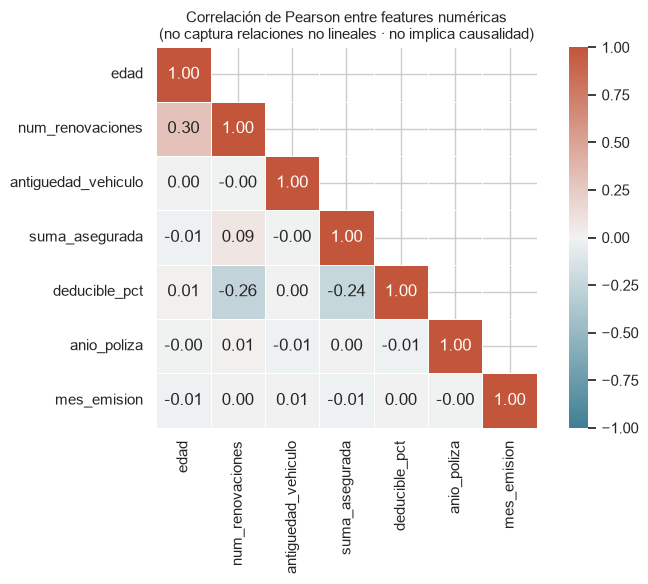

Pares con |correlación| > 0.10:
num_renovaciones  edad                0.297468
deducible_pct     num_renovaciones    0.258546
                  suma_asegurada      0.240640


In [13]:
# Heatmap de correlación solo entre features numéricas (no targets)
numeric_feat_cols = [
    "edad", "num_renovaciones", "antiguedad_vehiculo",
    "suma_asegurada", "deducible_pct", "anio_poliza", "mes_emision",
]
corr_mat = df[numeric_feat_cols].corr()

# Mostrar solo triángulo inferior (sin redundancia)
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_mat, mask=mask, annot=True, fmt=".2f",
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax,
)
ax.set_title(
    "Correlación de Pearson entre features numéricas\n"
    "(no captura relaciones no lineales · no implica causalidad)",
    fontsize=11,
)
plt.tight_layout(); plt.show()

print("Pares con |correlación| > 0.10:")
_upper = corr_mat.where(np.tril(np.ones_like(corr_mat, dtype=bool), k=-1))
_high = _upper.stack().abs()
print(_high[_high > 0.10].sort_values(ascending=False).to_string())

## 10. Leakage: qué NO usar como feature

El **leakage** ocurre cuando una variable que filtra información del target entra
como feature en el modelo. En este dataset hay tres tipos a evitar.

In [14]:
# Tabla de reglas de leakage para el Subtema 4
leakage_df = pd.DataFrame({
    "Tipo": ["A — directo", "A — directo", "B — clustering", "C — identificador"],
    "Si el target es...": [
        "siniestro_alto",
        "n_siniestros o monto_siniestro",
        "cualquier tarea de clustering",
        "(cualquier modelo)",
    ],
    "No incluir en X...": [
        "n_siniestros, monto_siniestro",
        "siniestro_alto, monto_siniestro",
        "TARGET_COLUMNS completo",
        "id_poliza_sin",
    ],
    "Razón": [
        "siniestro_alto = int(n_siniestros > 0) — relación determinística",
        "monto_siniestro = Σ severidad_k — función directa de n_siniestros",
        "Targets no forman clusters; se interpretan post-clustering (§2.2)",
        "Identificador secuencial sin información predictiva",
    ],
})
print(leakage_df.to_string(index=False, max_colwidth=52))

             Tipo             Si el target es...              No incluir en X...                                                Razón
      A — directo                 siniestro_alto   n_siniestros, monto_siniestro siniestro_alto = int(n_siniestros > 0) — relación...
      A — directo n_siniestros o monto_siniestro siniestro_alto, monto_siniestro monto_siniestro = Σ severidad_k — función directa...
   B — clustering  cualquier tarea de clustering         TARGET_COLUMNS completo Targets no forman clusters; se interpretan post-c...
C — identificador             (cualquier modelo)                   id_poliza_sin  Identificador secuencial sin información predictiva


**Verificación formal del Tipo A:**

$$\text{siniestro\_alto}_i = \mathbf{1}[n\_\text{siniestros}_i > 0]$$

Si $y_j = g(y_k)$ con $g$ conocida, incluir $y_k$ como feature para predecir $y_j$
viola la separación de inputs y outputs. El modelo aprendería la función $g$
en lugar del patrón actuarial real.

In [15]:
# Verificar la relación determinística entre siniestro_alto y n_siniestros
es_deterministica = (df["siniestro_alto"] == (df["n_siniestros"] > 0).astype(int)).all()
print(f"✓ siniestro_alto = int(n_siniestros > 0) para todas las {len(df):,} filas: {es_deterministica}")
print()
print("Features correctas para predecir siniestro_alto (S04.03, S04.07):")
print([c for c in FEATURE_COLUMNS])
print()
print("Features correctas para clustering (S04.09–S04.11):")
print(CLUSTERING_FEATURES)

✓ siniestro_alto = int(n_siniestros > 0) para todas las 30,000 filas: True

Features correctas para predecir siniestro_alto (S04.03, S04.07):
['anio_poliza', 'mes_emision', 'edad', 'sexo', 'estado_civil', 'num_renovaciones', 'region', 'plan', 'tipo_vehiculo', 'antiguedad_vehiculo', 'suma_asegurada', 'deducible_pct', 'forma_pago', 'canal_venta', 'nivel_riesgo_asignado']

Features correctas para clustering (S04.09–S04.11):
['edad', 'suma_asegurada', 'num_renovaciones', 'antiguedad_vehiculo']


## 11. Preparación común para notebooks posteriores

El template de abajo se copia en cada notebook S04.01–S04.11, cambiando
únicamente `target_col` y `feature_list` según la técnica.

> **Nota sobre `StandardScaler.fit_transform()`:** ajustar el escalador es
> *preprocesamiento*, no entrenamiento de un modelo de ML. Transforma variables
> numéricas a media 0 y desviación estándar 1. Obligatorio antes de SVM (S04.07),
> MLP (S04.08) y clustering (S04.09–S04.11). El `.fit()` se aplica **solo** sobre
> `X_train` para evitar data leakage de escala.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# == Template de carga estándar — copiar en cada notebook S04.0X ==
# Adaptar: target_col y feature_list según el módulo

target_col   = "prima_neta"       # <-- cambiar según el módulo
feature_list = FEATURE_COLUMNS    # columnas 2–16

X_raw = df[feature_list]
y     = df[target_col]

# Codificación one-hot de categóricas (drop_first=True evita multicolinealidad)
X = pd.get_dummies(X_raw, drop_first=True)
print(f"Dimensiones tras one-hot: X={X.shape}, y={y.shape}")

# Split 80/20 train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f"Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

# Escalado — obligatorio para SVM, MLP y clustering; opcional para árboles
# IMPORTANTE: fit() solo sobre X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # ajusta Y transforma
X_test_scaled  = scaler.transform(X_test)        # solo transforma (sin fit)

print(f"X_train_scaled: media≈{X_train_scaled.mean():.4f}, std≈{X_train_scaled.std():.4f}")
print()
print("Nota: StandardScaler es preprocesamiento. El modelo de ML se entrena")
print("en el notebook de cada técnica (S04.01 en adelante).")

Dimensiones tras one-hot: X=(30000, 30), y=(30000,)
Train: 24,000 filas | Test: 6,000 filas
X_train_scaled: media≈0.0000, std≈1.0000

Nota: StandardScaler es preprocesamiento. El modelo de ML se entrena
en el notebook de cada técnica (S04.01 en adelante).


## 12. Cierre y checklist para S04.01

### Resumen de lo aprendido en S04.00

| Tema | Resultado |
|------|-----------|
| Schema | 21 columnas: 1 índice + 15 features + 5 targets |
| Validaciones §6.4 | 7/7 pasan — dataset íntegro, sin nulos, reproducible |
| Distribución de riesgo | Bajo 31.8% · Medio 46.5% · Alto 21.6% |
| Siniestralidad | 28.3% de pólizas con al menos 1 siniestro |
| Relaciones diseñadas | prima_neta ↑ con suma_asegurada, plan Plus y nivel Alto; relación cuadrática con edad |
| Leakage | 3 tipos documentados (A directo, B clustering, C identificador) |
| Template de carga | Disponible para S04.01–S04.11 |

### Checklist para iniciar S04.01 — Regresión Lineal

- [ ] Target: `prima_neta` (variable continua, sesgo derecho moderado)
- [ ] Features: `FEATURE_COLUMNS` (columnas 2–16), codificadas con `pd.get_dummies(drop_first=True)`
- [ ] Split 80/20 con `random_state=20260618`
- [ ] No hay targets en `X`

### Pregunta guía para S04.01

> "¿Cuánto cambia la prima esperada en MXN por cada MXN adicional de suma asegurada,
> manteniendo constantes las demás características del asegurado?"

Esta es la interpretación del coeficiente $\hat{\beta}_1$ en:

$$\hat{y}_i = \hat{\beta}_0 + \hat{\beta}_1 \cdot \text{suma\_asegurada}_i + \cdots + \hat{\varepsilon}_i$$

---

### Referencias bibliográficas

- James, G., et al. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. Cap. 1–2.
- Unpingco, J. (2022). *Python for Probability, Statistics, and Machine Learning* (3rd ed.). Springer. §4.1–§4.2.
- Wüthrich, M. V., & Buser, C. *Data Analytics for Non-Life Insurance Pricing*. Swiss Finance Institute. Cap. 1.
- scikit-learn Developers. *User Guide* (v1.9.0). `StandardScaler`, `train_test_split`.
